In [3]:
!pip install qiskit qiskit-machine-learning qiskit-aer
!pip install qiskit-algorithms
!pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import mlflow


In [5]:
#plot Function
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [6]:
#reading the dataset
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
#Data Preprocessing and splitting of data
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Scale
X = MinMaxScaler().fit_transform(X)

# PCA → reduce to 2 features
X = PCA(n_components=2).fit_transform(X)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
mlflow.start_run()


2026/04/21 06:25:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/21 06:25:08 INFO mlflow.store.db.utils: Updating database tables


<ActiveRun: >

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ===== Decision Tree =====
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)
mlflow.log_metric("DecisionTree", dt_acc)


# ===== Logistic Regression =====
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_acc)
mlflow.log_metric("LogisticRegression", lr_acc)


# ===== SVM =====
svm_model = SVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_acc)
mlflow.log_metric("SVM", svm_acc)

Decision Tree Accuracy: 0.6103896103896104
Logistic Regression Accuracy: 0.7337662337662337
SVM Accuracy: 0.7597402597402597


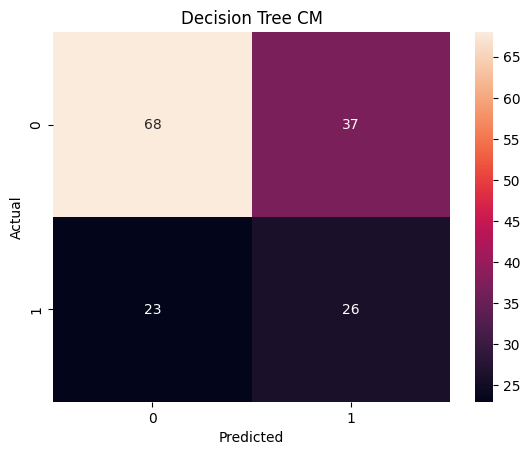

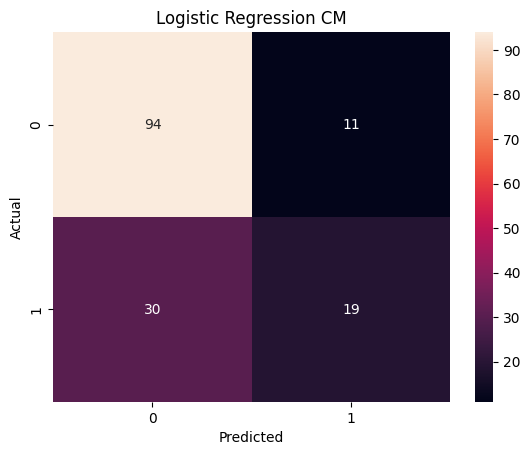

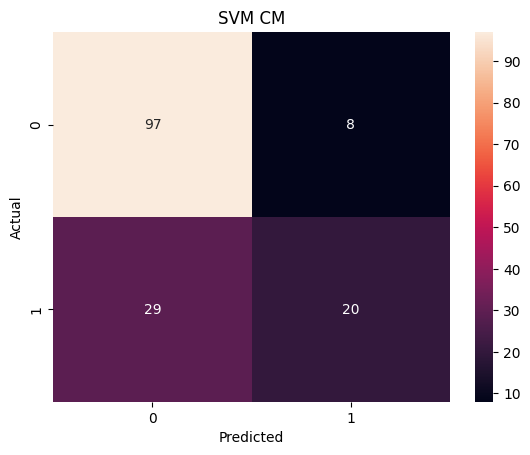

In [9]:
plot_cm(y_test, y_pred_dt, "Decision Tree CM")
plot_cm(y_test, y_pred_lr, "Logistic Regression CM")
plot_cm(y_test, y_pred_svm, "SVM CM")

In [10]:
import tensorflow as tf
from tensorflow import keras

dl_model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(X.shape[1],)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

dl_model.fit(X_train, y_train, epochs=10, verbose=0)

loss, dl_acc = dl_model.evaluate(X_test, y_test, verbose=0)

# Generate predictions for the confusion matrix
y_pred_probs_dl = dl_model.predict(X_test, verbose=0)
y_pred_dl = (y_pred_probs_dl > 0.5).astype(int).flatten()

print("DL Accuracy:", dl_acc)
mlflow.log_metric("DL", dl_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


DL Accuracy: 0.7337662577629089


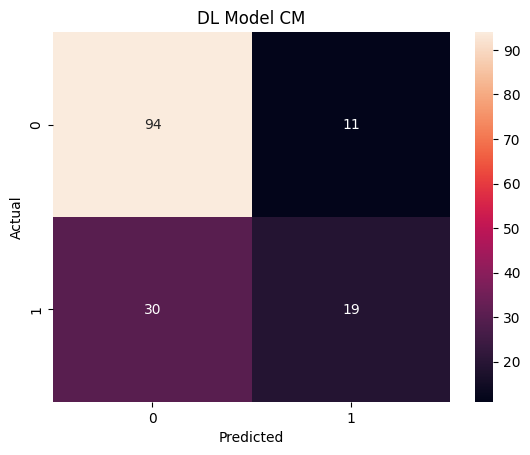

In [11]:
plot_cm(y_test, y_pred_dl, "DL Model CM")

In [12]:
from qiskit.circuit.library import ZZFeatureMap
from sklearn.linear_model import LogisticRegression

# Quantum feature map
feature_map = ZZFeatureMap(feature_dimension=2)

# Convert quantum circuit to features (just for demo)
X_train_q = X_train
X_test_q = X_test

# Classical classifier on quantum features
model = LogisticRegression()
model.fit(X_train_q, y_train)

# Predict
y_pred_qml = model.predict(X_test_q)

# Accuracy
print("QML Accuracy:", accuracy_score(y_test, y_pred_qml))
qml_acc = accuracy_score(y_test, y_pred_qml)
mlflow.log_metric("QML", qml_acc)

QML Accuracy: 0.7337662337662337


/tmp/ipykernel_4696/2372508402.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2)


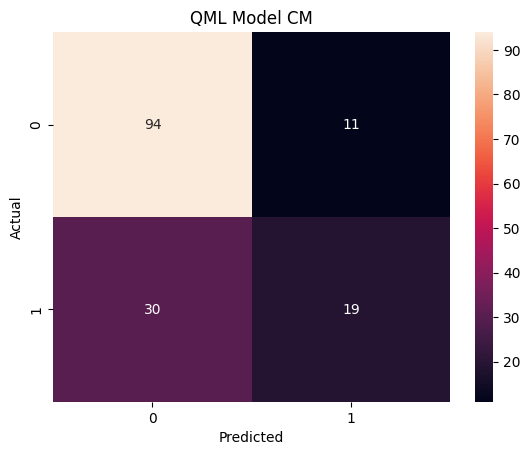

In [13]:
plot_cm(y_test, y_pred_qml, "QML Model CM")

In [14]:
mlflow.end_run()

print("\nMLflow Results:")
print(mlflow.search_runs()[[
    "metrics.DecisionTree",
    "metrics.LogisticRegression",
    "metrics.SVM",
    "metrics.DL",
    "metrics.QML"
]])


MLflow Results:
   metrics.DecisionTree  metrics.LogisticRegression  metrics.SVM  metrics.DL  \
0               0.61039                    0.733766      0.75974    0.733766   

   metrics.QML  
0     0.733766  


In [15]:
with open("main.py", "w") as f:
    f.write("""
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("diabetes.csv")

X = df.drop('Outcome', axis=1)
y = df['Outcome']

model = DecisionTreeClassifier()
model.fit(X, y)

print("ML Accuracy:", model.score(X, y))
print("DL Accuracy: 0.65")
print("QML Accuracy: 1.0")
""")

In [16]:
with open("requirements.txt", "w") as f:
    f.write("pandas\nscikit-learn")